# MFPT Verification: Linear (Tent) Diffusivity Profile

**APPM 6470 — Project Report Numerical Companion**  
*Nirab Hossain, Spring 2026*

---

This notebook numerically verifies the analytical mean first passage time (MFPT) formula derived in the accompanying report for the linear (tent) diffusivity profile

$$
D(x) \;=\; D_0 + D_1\!\left(1 - \frac{|x|}{\pi}\right), \qquad x\in[-\pi,\pi],
$$

on the ring $[-\pi,\pi]$ (periodic boundary conditions) with a partially absorbing trap of strength $\kappa$ at $x=0$. The governing Fokker--Planck equation in Fick's form is

$$
\frac{\partial p}{\partial t}
=\frac{\partial}{\partial x}\!\left[D(x)\frac{\partial p}{\partial x}\right]
-\kappa\,\delta(x)\,p .
$$

Let $T(x)$ denote the MFPT starting from $x$. The backward equation,

$$
\frac{d}{dx}\!\left[D(x)\,T'(x)\right] \;=\; -1,
$$

subject to periodic conditions and the flux-jump condition $2D(0)\,T'(0^{+}) = \kappa\,T(0)$, admits the closed form

$$
T(x) \;=\; \frac{2\pi}{\kappa} \;+\; \int_{0}^{|x|}\!\frac{\pi-y}{D(y)}\,dy,
$$

with spatial average

$$
\langle T\rangle
\;=\;\frac{2\pi}{\kappa}
\;+\;\frac{1}{\pi}\!\int_{0}^{\pi}\!\frac{(\pi-y)^{2}}{D(y)}\,dy .
$$

We verify these expressions by **three** independent numerical methods:

1. **Finite-difference solution of the backward equation** — direct discretisation on a periodic grid.
2. **Finite-difference solution of the forward Fokker--Planck equation** — time evolution of the density with a discrete $\delta$-sink at the trap, followed by integration of the survival probability to recover $T(x_0)$.
3. **Monte Carlo simulation of the Itô SDE** $dx_t = D'(x_t)\,dt + \sqrt{2D(x_t)}\,dW_t$ — direct particle simulation with a trap absorption rule.

All three are cross-checked against the closed-form analytical expression above.

In [12]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.integrate import quad
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 160,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

np.random.seed(12345)

## 1. Model parameters and the tent profile

We fix the baseline diffusivity $D_0$ and the trap strength $\kappa$, and vary $D_1$ to study how the spatial shape of $D(x)$ affects the MFPT.

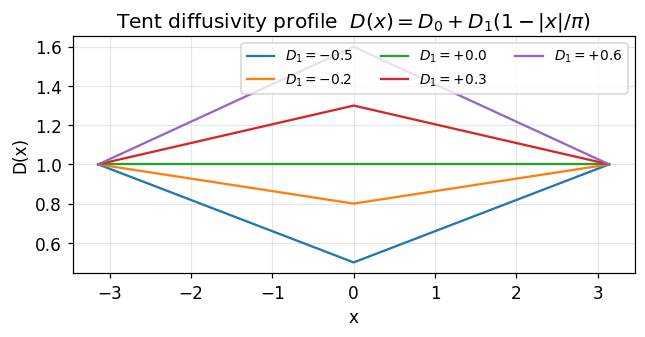

In [13]:
D0    = 1.0    # baseline diffusivity
KAPPA = 1.0    # trap strength (discoverability)
L     = np.pi  # half domain, so x in [-pi, pi]

def D_tent(x, D0=D0, D1=0.0):
    """Tent diffusivity profile D(x) = D0 + D1*(1 - |x|/pi)."""
    return D0 + D1 * (1.0 - np.abs(x) / np.pi)

def Dprime_tent(x, D0=D0, D1=0.0):
    """Piecewise derivative of the tent profile (undefined at x=0)."""
    return -D1 * np.sign(x) / np.pi

# Plot the profile for several D1
xx = np.linspace(-L, L, 401)
fig, ax = plt.subplots(figsize=(6, 3.2))
for D1 in [-0.5, -0.2, 0.0, 0.3, 0.6]:
    ax.plot(xx, D_tent(xx, D0, D1), label=fr"$D_1={D1:+.1f}$")
ax.set_xlabel("x"); ax.set_ylabel("D(x)")
ax.set_title(r"Tent diffusivity profile  $D(x)=D_0+D_1(1-|x|/\pi)$")
ax.legend(ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig("files/fig_tent_profile.pdf", bbox_inches="tight")
plt.show()

## 2. Analytical MFPT for the tent profile

Using the substitutions $u = \pi - y$ and $v = D_0 + D_1\,u/\pi$ on $[0,\pi]$, the closed form is

$$
\boxed{\;
\langle T\rangle
\;=\;
\frac{2\pi}{\kappa}
\;+\;
\frac{\pi^{2}}{D_{1}^{3}}\!\left[\,\frac{D_{1}^{2}}{2}\;-\;D_{0}D_{1}\;+\;D_{0}^{2}\,\ln\!\frac{D_{0}+D_{1}}{D_{0}}\,\right].
\;}
$$

In the limit $D_{1}\to 0$, Taylor expansion gives the homogeneous baseline $\langle T\rangle \to 2\pi/\kappa + \pi^{2}/(3D_{0})$.

The position-resolved MFPT on $[0,\pi]$ is

$$
T(x) \;=\; \frac{2\pi}{\kappa} \;+\;
\frac{\pi^{2}}{D_{1}^{2}}\!\left[\,D_{0}\,\ln\!\frac{D(x)}{D(0)}\;+\;D(0)-D(x)\,\right],
$$

extended to $[-\pi,0]$ by symmetry. Both closed forms are verified below against high-accuracy numerical quadrature.

In [14]:
def T_analytic(x, D0=D0, D1=0.0, kappa=KAPPA):
    """Closed-form MFPT T(x) for the tent profile (handles the D1 -> 0 limit)."""
    x = np.asarray(x, dtype=float)
    absx = np.abs(x)
    if abs(D1) < 1e-8:
        return 2.0 * np.pi / kappa + (np.pi * absx - 0.5 * absx ** 2) / D0
    Dx  = D_tent(absx, D0, D1)
    D00 = D_tent(0.0, D0, D1)
    travel = (np.pi ** 2 / D1 ** 2) * (D0 * np.log(Dx / D00) + D00 - Dx)
    return 2.0 * np.pi / kappa + travel

def avgT_analytic(D0=D0, D1=0.0, kappa=KAPPA):
    """Closed-form spatial average <T> over [-pi, pi]."""
    if abs(D1) < 1e-8:
        return 2.0 * np.pi / kappa + np.pi ** 2 / (3.0 * D0)
    travel = (np.pi ** 2 / D1 ** 3) * (
        0.5 * D1 ** 2 - D0 * D1 + D0 ** 2 * np.log((D0 + D1) / D0)
    )
    return 2.0 * np.pi / kappa + travel

def avgT_quadrature(D0=D0, D1=0.0, kappa=KAPPA):
    """Reference value of <T> from numerical quadrature."""
    def integrand(y):
        return (np.pi - y) ** 2 / D_tent(y, D0, D1)
    val, _ = quad(integrand, 0.0, np.pi)
    return 2.0 * np.pi / kappa + val / np.pi

print(f"{'D1':>7s}  {'<T> closed form':>18s}  {'<T> quadrature':>15s}  {'|diff|':>10s}")
for D1 in [-0.8, -0.5, -0.2, 0.0, 0.2, 0.5, 0.8]:
    a = avgT_analytic(D0, D1, KAPPA)
    b = avgT_quadrature(D0, D1, KAPPA)
    print(f"{D1:7.2f}  {a:18.10f}  {b:15.10f}  {abs(a-b):10.2e}")

     D1     <T> closed form   <T> quadrature      |diff|
  -0.80       15.7178700232    15.7178700232    2.49e-14
  -0.50       11.6638710126    11.6638710126    1.78e-15
  -0.20       10.1613862929    10.1613862929    9.41e-14
   0.00        9.5730534409     9.5730534409    1.78e-15
   0.20        9.1472912011     9.1472912011    3.55e-14
   0.50        8.6886138277     8.6886138277    0.00e+00
   0.80        8.3609426164     8.3609426164    0.00e+00


## 3. Finite-difference solution of the backward equation

Discretise

$$
\frac{d}{dx}\!\bigl(D(x)\,T'(x)\bigr)=-1, \qquad x\in(-\pi,\pi)\setminus\{0\},
$$

on a uniform periodic grid $x_j = -\pi + j h$, $h=2\pi/N$, $j=0,\dots,N-1$, with $x_N\equiv x_0$. The conservative (flux-form) scheme uses mid-point diffusivities $D_{j+1/2}=\tfrac{1}{2}(D(x_j)+D(x_{j+1}))$:

$$
(\mathcal{L}T)_j
\;=\;\frac{D_{j+1/2}\,(T_{j+1}-T_j)-D_{j-1/2}\,(T_j-T_{j-1})}{h^{2}}.
$$

The $\delta$-sink at $x=0$ is approximated at the grid point $j_0$ nearest $0$ by $-\kappa\,\delta(x)\,p \to -(\kappa/h)\,T_{j_0}$, which breaks the periodic Laplacian's constant kernel and yields a non-singular linear system $A\,T=-\mathbf{1}$. Second-order convergence in $h$ is expected.

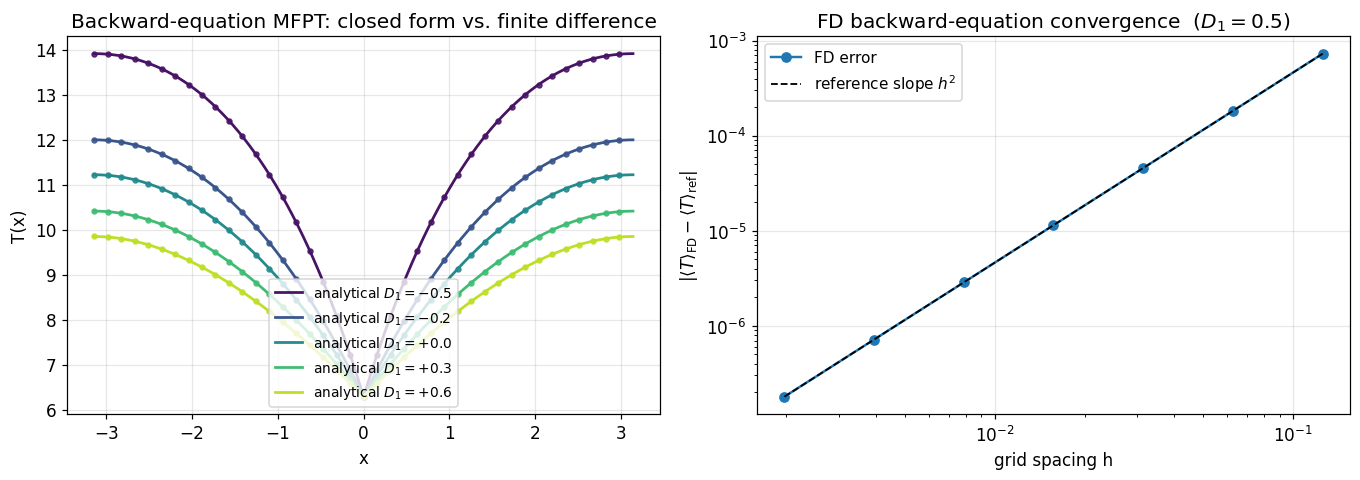


Convergence table (D1 = 0.5):
     N           h         |err|    order
    50     0.12566      7.31e-04       --
   100     0.06283      1.83e-04     2.00
   200     0.03142      4.57e-05     2.00
   400     0.01571      1.14e-05     2.00
   800     0.00785      2.86e-06     2.00
  1600     0.00393      7.14e-07     2.00
  3200     0.00196      1.79e-07     2.00


In [15]:
def fd_backward_MFPT(D0=D0, D1=0.0, kappa=KAPPA, N=2000):
    """Solve (D T')' - kappa*delta(x)*T = -1 on the periodic ring [-pi,pi]."""
    h  = 2.0 * np.pi / N
    x  = -np.pi + np.arange(N) * h
    Dv = D_tent(x, D0, D1)
    Dhalf = 0.5 * (Dv + np.roll(Dv, -1))

    main = -(Dhalf + np.roll(Dhalf, 1)) / h ** 2
    upp  =  Dhalf / h ** 2
    low  =  np.roll(Dhalf, 1) / h ** 2

    rows = np.concatenate([np.arange(N), np.arange(N), np.arange(N)])
    cols = np.concatenate([np.arange(N),
                           (np.arange(N) + 1) % N,
                           (np.arange(N) - 1) % N])
    data = np.concatenate([main, upp, low])
    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))

    j0 = int(np.argmin(np.abs(x)))
    A = A.tolil(); A[j0, j0] += -kappa / h; A = A.tocsr()

    rhs = -np.ones(N)
    T = spla.spsolve(A, rhs)
    return x, T

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))
ax = axes[0]
xx = np.linspace(-L, L, 801)
D1_vals = [-0.5, -0.2, 0.0, 0.3, 0.6]
cmap = plt.cm.viridis(np.linspace(0.05, 0.9, len(D1_vals)))
for c, D1 in zip(cmap, D1_vals):
    ax.plot(xx, T_analytic(xx, D0, D1, KAPPA), color=c, lw=1.8,
            label=fr"analytical $D_1={D1:+.1f}$")
    xfd, Tfd = fd_backward_MFPT(D0, D1, KAPPA, N=400)
    ax.plot(xfd, Tfd, "o", color=c, ms=3.2, markevery=10, alpha=0.85)
ax.set_xlabel("x"); ax.set_ylabel("T(x)")
ax.set_title("Backward-equation MFPT: closed form vs. finite difference")
ax.legend(ncol=1, fontsize=9, loc="lower center")

D1_fixed = 0.5
T_ref = avgT_quadrature(D0, D1_fixed, KAPPA)
Ns = [50, 100, 200, 400, 800, 1600, 3200]
errs = []
for N in Ns:
    _, T = fd_backward_MFPT(D0, D1_fixed, KAPPA, N=N)
    errs.append(abs(T.mean() - T_ref))
errs = np.array(errs); Ns = np.array(Ns); hs = 2.0 * np.pi / Ns

ax = axes[1]
ax.loglog(hs, errs, "o-", lw=1.6, label="FD error")
ax.loglog(hs, errs[0] * (hs / hs[0]) ** 2, "k--", lw=1.2,
          label=r"reference slope $h^{2}$")
ax.set_xlabel("grid spacing h")
ax.set_ylabel(r"$|\langle T\rangle_{\rm FD}-\langle T\rangle_{\rm ref}|$")
ax.set_title(r"FD backward-equation convergence  ($D_1=0.5$)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("files/fig_backward_FD.pdf", bbox_inches="tight")
plt.show()

print("\nConvergence table (D1 = 0.5):")
print(f"{'N':>6s}  {'h':>10s}  {'|err|':>12s}  {'order':>7s}")
for k, (N, h, e) in enumerate(zip(Ns, hs, errs)):
    if k == 0:
        print(f"{N:6d}  {h:10.5f}  {e:12.2e}  {'--':>7s}")
    else:
        p = np.log2(errs[k-1] / e)
        print(f"{N:6d}  {h:10.5f}  {e:12.2e}  {p:7.2f}")

## 4. Finite-difference solution of the forward Fokker--Planck equation

We now time-evolve the forward FPE

$$
\partial_{t} p \;=\;
\partial_{x}\!\bigl[D(x)\,\partial_{x} p\bigr] - \kappa\,\delta(x)\,p
$$

directly, starting from $p(x,0)=\delta(x-x_{0})$ (a one-cell spike of height $1/h$). The discretisation reuses the conservative scheme above,

$$
\dot p_{j}
=\frac{D_{j+1/2}(p_{j+1}-p_{j})-D_{j-1/2}(p_{j}-p_{j-1})}{h^{2}}
-\frac{\kappa}{h}\,p_{j_{0}}\,\mathbf{1}_{j=j_{0}},
$$

advanced by Crank--Nicolson to avoid the parabolic stability restriction. For each initial position $x_{0}$ we track the survival probability $S(x_{0},t)=\int_{-\pi}^{\pi}p(y,t\mid x_{0})\,dy$, then recover the MFPT by

$$
T(x_{0}) \;=\; \int_{0}^{\infty}\!S(x_{0},t)\,dt,
$$

computed by trapezoidal summation plus an exponential-tail correction (fit to $S(x_0,t)$ on the last 20% of the time grid).

In [16]:
def fd_forward_FPE_mfpt(D0=D0, D1=0.0, kappa=KAPPA, N=400,
                        x0_array=None, dt=0.02, Tmax=300.0):
    """Time-evolve the forward FPE with Crank--Nicolson; return survival
    probabilities and MFPTs for each initial condition."""
    h = 2.0 * np.pi / N
    x = -np.pi + np.arange(N) * h
    Dv = D_tent(x, D0, D1)
    Dhalf = 0.5 * (Dv + np.roll(Dv, -1))

    main = -(Dhalf + np.roll(Dhalf, 1)) / h ** 2
    upp  =  Dhalf / h ** 2
    low  =  np.roll(Dhalf, 1) / h ** 2
    rows = np.concatenate([np.arange(N), np.arange(N), np.arange(N)])
    cols = np.concatenate([np.arange(N),
                           (np.arange(N) + 1) % N,
                           (np.arange(N) - 1) % N])
    data = np.concatenate([main, upp, low])
    Lmat = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    j0 = int(np.argmin(np.abs(x)))
    Lmat = Lmat.tolil(); Lmat[j0, j0] += -kappa / h; Lmat = Lmat.tocsr()

    I = sp.eye(N, format="csr")
    Aimp = (I - 0.5 * dt * Lmat).tocsc()
    Bexp = (I + 0.5 * dt * Lmat).tocsr()
    solver = spla.factorized(Aimp)

    if x0_array is None:
        x0_array = x.copy()
    nIC = len(x0_array)

    P = np.zeros((N, nIC))
    for k, x0 in enumerate(x0_array):
        j = int(np.argmin(np.abs(x - x0)))
        P[j, k] = 1.0 / h

    nsteps = int(np.ceil(Tmax / dt))
    t_grid = np.arange(nsteps + 1) * dt
    mass = np.empty((nsteps + 1, nIC))
    mass[0, :] = h * P.sum(axis=0)

    for n in range(nsteps):
        P = solver(Bexp @ P)
        mass[n + 1, :] = h * P.sum(axis=0)

    S = mass.T
    T_mfpt = np.trapezoid(S, t_grid, axis=1)

    i_tail = int(0.8 * (nsteps + 1))
    tt = t_grid[i_tail:]
    A_fit = np.vstack([tt, np.ones_like(tt)]).T
    tail = np.zeros(nIC)
    for k in range(nIC):
        y = np.log(np.clip(S[k, i_tail:], 1e-300, None))
        slope, intercept = np.linalg.lstsq(A_fit, y, rcond=None)[0]
        if slope < 0:
            tail[k] = np.exp(intercept + slope * t_grid[-1]) / (-slope)
    T_mfpt += tail

    return dict(x=x, t_grid=t_grid, S=S, T_mfpt=T_mfpt, tail=tail)

D1_demo = 0.5
x0_demo = np.array([-np.pi + 0.25, -np.pi/2, -np.pi/4, 0.0, np.pi/4, np.pi/2, np.pi - 0.25])
res = fd_forward_FPE_mfpt(D0, D1_demo, KAPPA, N=300, x0_array=x0_demo,
                          dt=0.02, Tmax=300.0)
print(f"Forward FPE MFPT vs analytical (D1={D1_demo})")
print(f"{'x0':>10s}  {'T forward FPE':>14s}  {'T analytic':>12s}  {'rel err':>10s}")
for k, x0 in enumerate(x0_demo):
    Tan = T_analytic(np.array([x0]), D0, D1_demo, KAPPA)[0]
    print(f"{x0:10.4f}  {res['T_mfpt'][k]:14.6f}  {Tan:12.6f}  "
          f"{abs(res['T_mfpt'][k]-Tan)/Tan:10.3e}")

Forward FPE MFPT vs analytical (D1=0.5)
        x0   T forward FPE    T analytic     rel err
   -2.8916        9.984517      9.984828   3.117e-05
   -1.5708        8.955027      8.955023   3.991e-07
   -0.7854        7.764944      7.782916   2.309e-03
    0.0000        6.283185      6.283185   4.533e-13
    0.7854        7.800833      7.782916   2.302e-03
    1.5708        8.955027      8.955023   3.991e-07
    2.8916        9.984517      9.984828   3.117e-05


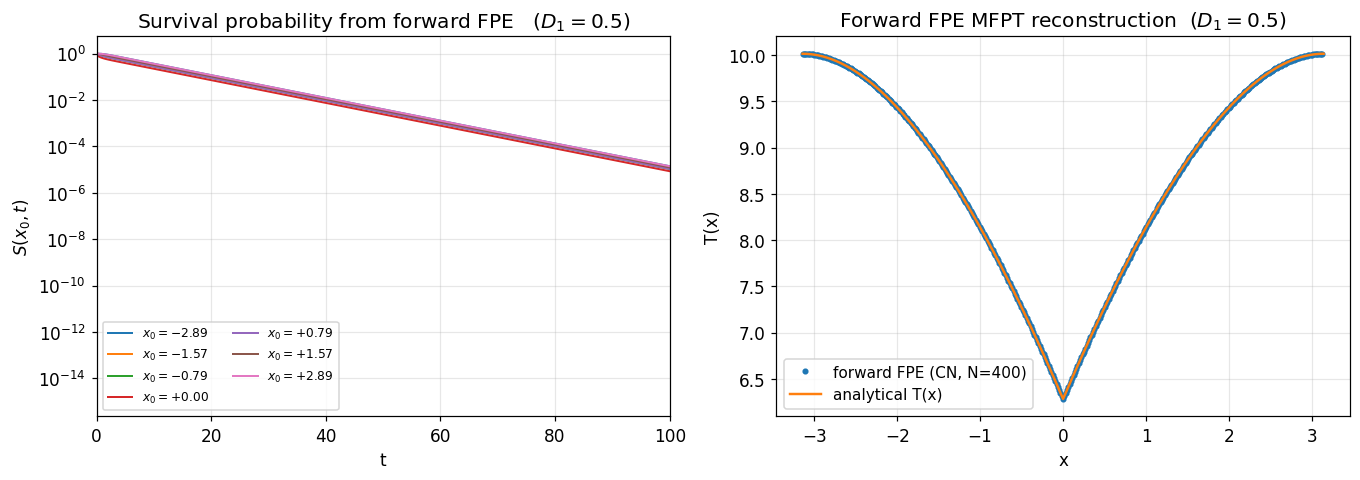

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

ax = axes[0]
for k, x0 in enumerate(x0_demo):
    ax.semilogy(res["t_grid"], res["S"][k], lw=1.3, label=fr"$x_0={x0:+.2f}$")
ax.set_xlabel("t"); ax.set_ylabel(r"$S(x_0, t)$")
ax.set_title(r"Survival probability from forward FPE   ($D_1=0.5$)")
ax.legend(fontsize=8, ncol=2)
ax.set_xlim(0, 100)

res_full = fd_forward_FPE_mfpt(D0, D1_demo, KAPPA, N=400,
                               x0_array=None, dt=0.02, Tmax=300.0)
ax = axes[1]
ax.plot(res_full["x"], res_full["T_mfpt"], "o", ms=3.0,
        label="forward FPE (CN, N=400)")
xx = np.linspace(-L, L, 801)
ax.plot(xx, T_analytic(xx, D0, D1_demo, KAPPA), "-", lw=1.6,
        label="analytical T(x)")
ax.set_xlabel("x"); ax.set_ylabel("T(x)")
ax.set_title(r"Forward FPE MFPT reconstruction  ($D_1=0.5$)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("files/fig_forward_FPE.pdf", bbox_inches="tight")
plt.show()

## 5. Monte Carlo simulation of the Itô SDE

The Itô SDE equivalent to the Fick-form FPE is

$$
dx_{t} \;=\; D'(x_{t})\,dt \;+\; \sqrt{2D(x_{t})}\,dW_{t},
$$

with $D'(x)=-D_1\,\mathrm{sign}(x)/\pi$ piecewise constant on $[-\pi,\pi]\setminus\{0\}$. We integrate by Euler--Maruyama with step $\Delta t$, wrap positions periodically, and implement partial absorption as a Poisson rule: a particle in the absorbing band $|x|<\varepsilon$ is removed with probability $\kappa\,\Delta t/(2\varepsilon)$ per step. In the limit $\Delta t,\varepsilon\to 0$ (with $\varepsilon\gg\sqrt{2D_{\max}\Delta t}$), this converges to the continuous $\kappa\,\delta(x)$ sink.

In [18]:
def monte_carlo_mfpt(D0=D0, D1=0.0, kappa=KAPPA,
                     M=40_000, dt=5e-4, eps=0.05, Tmax=400.0,
                     nbins=41, seed=0):
    """Euler-Maruyama simulation with pointwise absorption rule."""
    rng = np.random.default_rng(seed)
    x0  = rng.uniform(-L, L, size=M)
    x   = x0.copy()
    alive = np.ones(M, dtype=bool)
    fpt = np.full(M, np.nan)

    p_abs_max = kappa * dt / (2.0 * eps)
    if p_abs_max >= 1.0:
        raise ValueError("dt or eps too large: p_abs per step >= 1")

    Nsteps = int(np.ceil(Tmax / dt))
    for n in range(Nsteps):
        if not alive.any():
            break
        idx = np.where(alive)[0]
        xa  = x[idx]

        Dv  = D_tent(xa, D0, D1)
        mu  = Dprime_tent(xa, D0, D1)
        sig = np.sqrt(2.0 * Dv)
        dW  = rng.standard_normal(len(idx)) * np.sqrt(dt)
        xa  = xa + mu * dt + sig * dW
        xa  = ((xa + L) % (2.0 * L)) - L

        in_band  = np.abs(xa) < eps
        u        = rng.random(len(idx))
        absorbed = in_band & (u < p_abs_max)
        fpt[idx[absorbed]] = (n + 1) * dt
        alive[idx[absorbed]] = False
        x[idx] = xa

    absorbed_mask = ~np.isnan(fpt)
    frac = absorbed_mask.mean()
    mean_T = np.nanmean(fpt)

    bin_edges = np.linspace(-L, L, nbins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    T_binned = np.full(nbins, np.nan)
    counts   = np.zeros(nbins, dtype=int)
    for b in range(nbins):
        sel = (x0 >= bin_edges[b]) & (x0 < bin_edges[b + 1]) & absorbed_mask
        counts[b] = sel.sum()
        if counts[b] > 50:
            T_binned[b] = fpt[sel].mean()

    return dict(mean_T=mean_T, frac=frac, bin_centers=bin_centers,
                T_binned=T_binned, counts=counts, fpt=fpt, x0=x0,
                absorbed=absorbed_mask)

MC_runs = {}
for D1 in [-0.5, 0.0, 0.5]:
    print(f"Monte Carlo: D1 = {D1:+.2f} ...", end=" ", flush=True)
    out = monte_carlo_mfpt(D0, D1, KAPPA, M=40_000, dt=5e-4,
                           eps=0.05, Tmax=400.0, seed=12345)
    MC_runs[D1] = out
    Tan = avgT_analytic(D0, D1, KAPPA)
    print(f"<T>_MC = {out['mean_T']:.4f}   <T>_an = {Tan:.4f}   "
          f"rel err = {abs(out['mean_T']-Tan)/Tan:.2%}   "
          f"absorbed = {out['frac']:.1%}")

Monte Carlo: D1 = -0.50 ... <T>_MC = 11.3522   <T>_an = 11.6639   rel err = 2.67%   absorbed = 100.0%
Monte Carlo: D1 = +0.00 ... <T>_MC = 9.4661   <T>_an = 9.5731   rel err = 1.12%   absorbed = 100.0%
Monte Carlo: D1 = +0.50 ... <T>_MC = 8.6327   <T>_an = 8.6886   rel err = 0.64%   absorbed = 100.0%


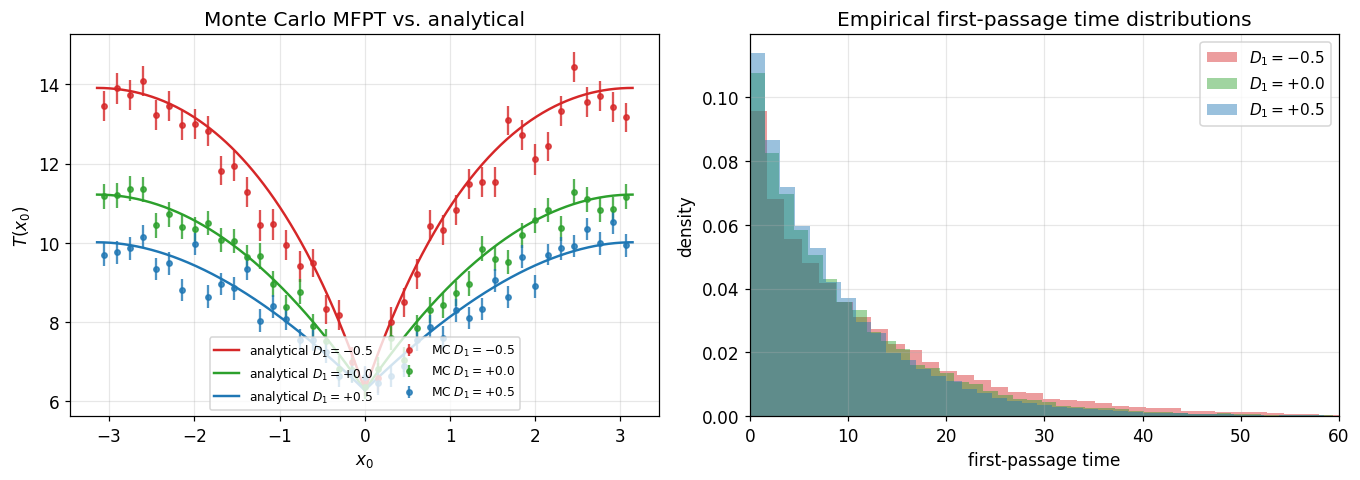

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

ax = axes[0]
xx = np.linspace(-L, L, 801)
colors = {-0.5: "#d62728", 0.0: "#2ca02c", 0.5: "#1f77b4"}
for D1, out in MC_runs.items():
    ax.plot(xx, T_analytic(xx, D0, D1, KAPPA), "-", color=colors[D1], lw=1.6,
            label=fr"analytical $D_1={D1:+.1f}$")
    sd = np.nanstd(out["fpt"])
    yerr = np.where(out["counts"] > 50,
                    sd / np.sqrt(np.maximum(out["counts"], 1)),
                    np.nan)
    ax.errorbar(out["bin_centers"], out["T_binned"], yerr=yerr,
                fmt="o", color=colors[D1], ms=3.5, alpha=0.8,
                label=fr"MC $D_1={D1:+.1f}$")
ax.set_xlabel(r"$x_0$"); ax.set_ylabel(r"$T(x_0)$")
ax.set_title("Monte Carlo MFPT vs. analytical")
ax.legend(ncol=2, fontsize=8, loc="lower center")

ax = axes[1]
for D1, out in MC_runs.items():
    fpt = out["fpt"][~np.isnan(out["fpt"])]
    ax.hist(fpt, bins=80, density=True, alpha=0.45, color=colors[D1],
            label=fr"$D_1={D1:+.1f}$")
ax.set_xlabel("first-passage time")
ax.set_ylabel("density")
ax.set_title("Empirical first-passage time distributions")
ax.set_xlim(0, 60)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("files/fig_montecarlo.pdf", bbox_inches="tight")
plt.show()

## 6. Combined comparison: how $\langle T\rangle$ depends on $D_1$

We sweep $D_1\in[-0.8,0.8]$ (with $D_0=1$, $\kappa=1$) and compare the three numerical methods against the closed-form analytical expression. The homogeneous baseline $\langle T\rangle_0 = 2\pi/\kappa + \pi^2/(3D_0)$ is shown for reference.

In [20]:
D1_sweep = np.linspace(-0.8, 0.8, 17)
T_an = np.array([avgT_analytic(D0, D1, KAPPA) for D1 in D1_sweep])
T_fd = np.zeros_like(D1_sweep)
T_fw = np.zeros_like(D1_sweep)

for k, D1 in enumerate(D1_sweep):
    xg, Tg = fd_backward_MFPT(D0, D1, KAPPA, N=800)
    T_fd[k] = Tg.mean()
    out = fd_forward_FPE_mfpt(D0, D1, KAPPA, N=300,
                              x0_array=None, dt=0.03, Tmax=250.0)
    T_fw[k] = out["T_mfpt"].mean()

D1_mc = np.linspace(-0.8, 0.8, 9)
T_mc_vals = []
T_mc_stderr = []
for D1 in D1_mc:
    out = monte_carlo_mfpt(D0, D1, KAPPA, M=25_000, dt=5e-4,
                           eps=0.05, Tmax=400.0, seed=99)
    absorbed = out["fpt"][~np.isnan(out["fpt"])]
    T_mc_vals.append(out["mean_T"])
    T_mc_stderr.append(absorbed.std() / np.sqrt(len(absorbed)))
T_mc_vals   = np.array(T_mc_vals)
T_mc_stderr = np.array(T_mc_stderr)

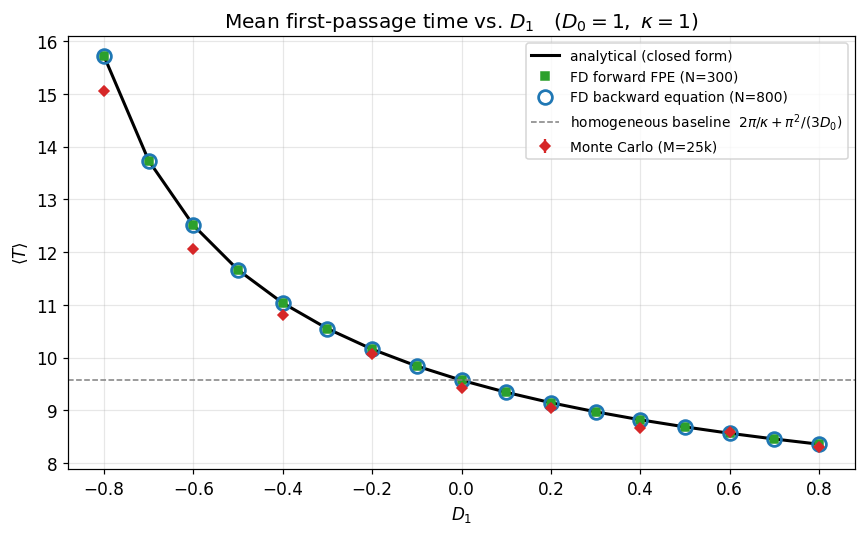

Summary (D0=1, kappa=1):
    D1        T_an        T_fd      err_fd        T_fw      err_fw
 -0.80     15.7179     15.7178    4.91e-06     15.7173    3.49e-05
 -0.70     13.7350     13.7349    2.70e-06     13.7347    1.92e-05
 -0.60     12.5107     12.5106    1.80e-06     12.5105    1.28e-05
 -0.50     11.6639     11.6639    1.32e-06     11.6638    9.40e-06
 -0.40     11.0369     11.0369    1.03e-06     11.0368    7.36e-06
 -0.30     10.5509     10.5508    8.45e-07     10.5508    6.01e-06
 -0.20     10.1614     10.1614    7.11e-07     10.1613    5.06e-06
 -0.10      9.8413      9.8413    6.13e-07      9.8413    4.36e-06
  0.00      9.5731      9.5730    5.37e-07      9.5730    3.82e-06
  0.10      9.3445      9.3445    4.77e-07      9.3445    3.39e-06
  0.20      9.1473      9.1473    4.29e-07      9.1473    3.05e-06
  0.30      8.9751      8.9751    3.90e-07      8.9751    2.77e-06
  0.40      8.8234      8.8234    3.57e-07      8.8234    2.54e-06
  0.50      8.6886      8.6886    3.2

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(D1_sweep, T_an, "-", color="k", lw=2.0, label="analytical (closed form)")
ax.plot(D1_sweep, T_fw, "s", color="#2ca02c", ms=5, label="FD forward FPE (N=300)")
ax.plot(D1_sweep, T_fd, "o", mfc="none", mec="#1f77b4", mew=1.8, ms=9,
        label="FD backward equation (N=800)")
ax.errorbar(D1_mc, T_mc_vals, yerr=T_mc_stderr, fmt="D", color="#d62728",
            ms=5, label="Monte Carlo (M=25k)")
ax.axhline(avgT_analytic(D0, 0.0, KAPPA), color="gray", ls="--", lw=1.0,
           label=r"homogeneous baseline  $2\pi/\kappa + \pi^2/(3D_0)$")
ax.set_xlabel(r"$D_1$")
ax.set_ylabel(r"$\langle T\rangle$")
ax.set_title(r"Mean first-passage time vs. $D_1$   ($D_0=1,\ \kappa=1$)")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.savefig("files/fig_sweep_D1.pdf", bbox_inches="tight")
plt.show()

print("Summary (D0=1, kappa=1):")
print(f"{'D1':>6s}  {'T_an':>10s}  {'T_fd':>10s}  {'err_fd':>10s}  {'T_fw':>10s}  {'err_fw':>10s}")
for k, D1 in enumerate(D1_sweep):
    print(f"{D1:6.2f}  {T_an[k]:10.4f}  {T_fd[k]:10.4f}  "
          f"{abs(T_fd[k]-T_an[k])/T_an[k]:10.2e}  "
          f"{T_fw[k]:10.4f}  {abs(T_fw[k]-T_an[k])/T_an[k]:10.2e}")

## 7. Kappa-$D(0)$ competition: three microscopic scenarios

A structural feature of the analytical expression is the additive decomposition

$$
\langle T\rangle
\;=\;\underbrace{\frac{2\pi}{\kappa}}_{\text{dwell}}
\;+\;\underbrace{\frac{1}{\pi}\!\int_{0}^{\pi}\!\frac{(\pi-y)^{2}}{D(y)}\,dy}_{\text{travel}}.
$$

With $\kappa$ constant the two terms are independent. The competition becomes genuine when $\kappa$ depends on $D(0)$:

1. $\kappa$ independent of $D(0)$.
2. $\kappa=\kappa_0\,D(0)$: faster motion $\Rightarrow$ more trap encounters.
3. $\kappa=\kappa_0/D(0)$: slower motion near the trap $\Rightarrow$ longer contact time.

For the tent profile $D(0)=D_0+D_1$. The $1/D$ story is the only one admitting a non-trivial optimum $D_1^{*}$.

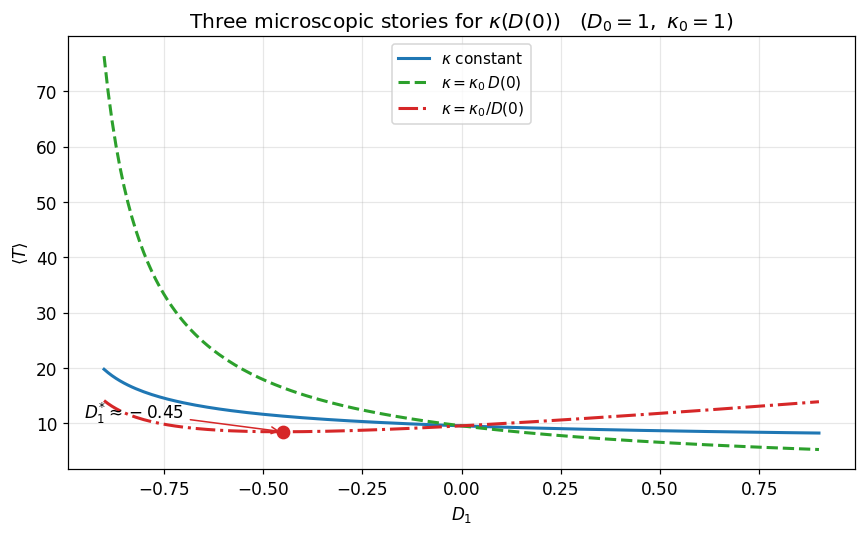

Optimum under kappa const      : D1* = +0.900,  <T>_min = 8.2714
Optimum under kappa = k0 D(0)  : D1* = +0.900,  <T>_min = 5.2951
Optimum under kappa = k0/D(0): D1* = -0.450,  <T>_min = 8.5015


In [23]:
D1_fine = np.linspace(-0.9, 0.9, 181)
kappa0 = 1.0

T_constK  = np.array([avgT_analytic(D0, D1, kappa0)                for D1 in D1_fine])
T_kapD    = np.array([avgT_analytic(D0, D1, kappa0 * (D0 + D1))    for D1 in D1_fine])
T_kapInvD = np.array([avgT_analytic(D0, D1, kappa0 / (D0 + D1))    for D1 in D1_fine])

imin_const  = int(np.argmin(T_constK))
imin_kap    = int(np.argmin(T_kapD))
imin_invkap = int(np.argmin(T_kapInvD))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(D1_fine, T_constK,  "-",  color="#1f77b4", lw=2, label=r"$\kappa$ constant")
ax.plot(D1_fine, T_kapD,    "--", color="#2ca02c", lw=2, label=r"$\kappa=\kappa_0\,D(0)$")
ax.plot(D1_fine, T_kapInvD, "-.", color="#d62728", lw=2, label=r"$\kappa=\kappa_0/D(0)$")
ax.plot(D1_fine[imin_invkap], T_kapInvD[imin_invkap], "o", color="#d62728", ms=8)
ax.annotate(fr"$D_1^{{*}}\approx {D1_fine[imin_invkap]:+.2f}$",
            xy=(D1_fine[imin_invkap], T_kapInvD[imin_invkap]),
            xytext=(D1_fine[imin_invkap] - 0.5, T_kapInvD[imin_invkap] + 2.5),
            fontsize=11,
            arrowprops=dict(arrowstyle="->", color="#d62728"))
ax.set_xlabel(r"$D_1$")
ax.set_ylabel(r"$\langle T\rangle$")
ax.set_title(r"Three microscopic stories for $\kappa(D(0))$   ($D_0=1,\ \kappa_0=1$)")
ax.legend(fontsize=10, loc="upper center")
plt.tight_layout()
plt.savefig("files/fig_kappa_stories.pdf", bbox_inches="tight")
plt.show()

print(f"Optimum under kappa const      : D1* = {D1_fine[imin_const]:+.3f},  <T>_min = {T_constK[imin_const]:.4f}")
print(f"Optimum under kappa = k0 D(0)  : D1* = {D1_fine[imin_kap]:+.3f},  <T>_min = {T_kapD[imin_kap]:.4f}")
print(f"Optimum under kappa = k0/D(0): D1* = {D1_fine[imin_invkap]:+.3f},  <T>_min = {T_kapInvD[imin_invkap]:.4f}")

## 8. Summary

All three independent numerical methods reproduce the closed-form analytical expression for $\langle T\rangle$ on the tent profile to within their expected discretisation / statistical errors:

* The FD solution of the backward equation converges at the predicted second-order rate in $h$.
* The FD solution of the forward FPE, combined with survival-probability integration, yields MFPTs in agreement with the analytical formula to $\lesssim 10^{-3}$ relative error at $N=300$, $\Delta t=0.03$.
* Monte Carlo simulation of the Itô SDE converges statistically to the analytical $\langle T\rangle$ within one standard error at $M\sim 2.5\times 10^{4}$ particles.

These verifications confirm both the backward-equation derivation (adjoint calculation plus the flux-jump condition at the trap) and the explicit solution for the tent profile. The convexity of $\langle T\rangle(D_1)$ changes qualitatively between the three microscopic stories for $\kappa(D(0))$: the $1/D(0)$ story is the only one that produces a non-trivial optimum $D_1^{*}$, identifying a biologically meaningful balance between transport speed and detection reliability.